In [0]:
import os
import random
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import torch
import torchvision
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch.utils.data import DataLoader

In [0]:
random.seed(0)
np.random.seed(0)
torch.manual_seed(0)
torch.cuda.manual_seed(0)
torch.backends.cudnn.deterministic = True

In [0]:
FashionMNIST_trn = torchvision.datasets.FashionMNIST(os.path.join(os.curdir, 'FashionMNIST'), download=True, train=True, transform=transforms.Compose([transforms.RandomResizedCrop(20),
                                                                                                                                                        transforms.RandomHorizontalFlip(),
                                                                                                                                                        transforms.RandomVerticalFlip(),
                                                                                                                                                        transforms.ToTensor()]))
FashionMNIST_tst = torchvision.datasets.FashionMNIST(os.path.join(os.curdir, 'FashionMNIST'), download=True, train=False, transform=transforms.Compose([transforms.ToTensor()]))

In [0]:
X_trn = FashionMNIST_trn.data
y_trn = FashionMNIST_trn.targets

In [0]:
X_tst = FashionMNIST_tst.data
y_tst = FashionMNIST_tst.targets

Text(0.5, 1.0, 'tensor(9)')

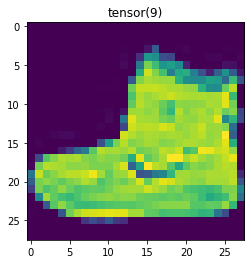

In [58]:
plt.imshow(X_trn[0])
plt.title(str(y_trn[0]))

In [59]:
X_trn[0].shape, 28*28

(torch.Size([28, 28]), 784)

In [0]:
X_trn = X_trn.unsqueeze(1).float()
X_tst = X_tst.unsqueeze(1).float()

In [0]:
class FashionMNIST(torch.nn.Module):
  def __init__(self, use_bn=True):
    super(FashionMNIST, self).__init__()

    # self.metric = 0
    self.use_bn = use_bn

    
    self.conv1 = torch.nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5, padding=2)
    self.act1 = torch.nn.ReLU()
    self.bn1 = torch.nn.BatchNorm2d(num_features=6)
    self.pool1 = torch.nn.MaxPool2d(kernel_size=2, stride=2)
    
    self.conv2 = torch.nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5, padding=2)
    self.act2 = torch.nn.ReLU()
    self.bn2 = torch.nn.BatchNorm2d(num_features=16)
    self.pool2 = torch.nn.MaxPool2d(kernel_size=2, stride=2)

    self.conv3 = torch.nn.Conv2d(in_channels=16, out_channels=24, kernel_size=4, padding=2)
    self.act3 = torch.nn.ReLU()
    self.bn3 = torch.nn.BatchNorm2d(num_features=24)
    self.pool3 = torch.nn.MaxPool2d(kernel_size=2, stride=2)
    
    self.fc1 = torch.nn.Linear(4 * 4 * 24, 120)
    self.act4 = torch.nn.ReLU()
    self.bn4 = torch.nn.BatchNorm1d(num_features=120)

    self.fc2 = torch.nn.Linear(120, 84)
    self.act5 = torch.nn.ReLU()
    self.bn5 = torch.nn.BatchNorm1d(num_features=84)
    
    self.fc3 = torch.nn.Linear(84, 10)
  
  def forward(self, x):
    x = self.conv1(x)
    x = self.act1(x)
    if self.use_bn:
      x = self.bn1(x)
    x = self.pool1(x)
    
    x = self.conv2(x)
    x = self.act2(x)
    if self.use_bn:
      x = self.bn2(x)
    x = self.pool2(x)

    x = self.conv3(x)
    x = self.act3(x)
    if self.use_bn:
      x = self.bn3(x)
    x = self.pool3(x)
    
    x = x.view(x.size(0), x.size(1) * x.size(2) * x.size(3))
    x = self.fc1(x)
    x = self.act4(x)
    if self.use_bn:
      x = self.bn4(x)

    x = self.fc2(x)
    x = self.act5(x)
    if self.use_bn:
      x = self.bn5(x)

    x = self.fc3(x)
    
    return x

In [0]:
def train(model,
          X_trn, y_trn,
          X_val, y_val,
          loss, optimizer, lr_scheduler,
          batch_size=100,
          epochs=30):
  
  device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
  model = model.to(device)
  loss = loss
  optimizer = optimizer
  lr_scheduler = lr_scheduler

  val_acc_hist = []
  val_loss_hist = []

  X_val = X_val.to(device)
  y_val = y_val.to(device)

  for epoch in range(epochs):
    order = np.random.permutation(len(X_trn))
    for start_idx in range(0, len(X_trn), batch_size):
      optimizer.zero_grad()
      model.train()
      
      batch_idx = order[start_idx:start_idx + batch_size]

      X_batch = X_trn[batch_idx].to(device)
      y_batch = y_trn[batch_idx].to(device)

      preds = model.forward(X_batch)

      loss_value = loss(preds, y_batch)
      loss_value.backward()

      optimizer.step()
      # lr_scheduler.step(model.metric)

    model.eval()
    val_preds = model.forward(X_val)
    val_loss_hist.append(loss(val_preds, y_val).data.cpu())
    accuracy = (val_preds.argmax(dim=1) == y_val).float().mean().data.cpu()
    val_acc_hist.append(accuracy)

    print(f'epoch {epoch}: {accuracy:.6f}')
  print('-----------------------------------')

  return val_acc_hist, val_loss_hist

In [0]:
model = FashionMNIST(use_bn=True)
loss = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
# lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer)

In [64]:
model_acc, model_loss = train(model,
                              X_trn, y_trn,
                              X_tst, y_tst,
                              loss, optimizer,lr_scheduler,
                              batch_size=200, epochs=7)

epoch 0: 0.879700
epoch 1: 0.885100
epoch 2: 0.898700
epoch 3: 0.897600
epoch 4: 0.897100
epoch 5: 0.891700
epoch 6: 0.904700
-----------------------------------


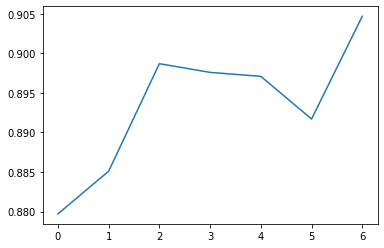

In [65]:
plt.plot(model_acc)

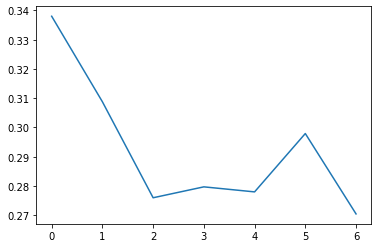

In [66]:
plt.plot(model_loss)